# Step 5 — Trigger Assessment

Evaluates how well a multi-gauge action trigger — "fire if N of the top gauges exceed a Y-year return period threshold in a given wet season" — detects Floodscan flood years. A grid search over (N, Y) pairs is scored against the Floodscan benchmark from Step 2 at 3-, 4-, and 5-year RP levels.

**Inputs** (from workflow blob storage):
- `{state}_selected_gauges.parquet` — top-N gauges from Step 4
- `{state}_floodscan_annual.parquet` — annual Floodscan maxima and flood event flags from Step 2

**Outputs** saved to blob storage:
```
ds-aa-nga-flooding/processed/workflow/{state}_trigger_grid.parquet
```
Columns: `rp_thresh`, `n_gauges`, `fs_rp`, `pod`, `far`, `f1`, `tp`, `fp`, `fn`, `n_activations`

**Next step**: `06_trigger_definition.ipynb` — select the final trigger configuration.

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from scipy import stats as scipy_stats

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.datasources.glofas import get_blob_name
from src.utils.rp_calc import empirical_return_periods

load_dotenv()

True

In [17]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Adamawa"  # "Adamawa" or "Benue"

WET_MONTHS   = [8, 9, 10, 11]
RP_LEVELS    = [2, 3, 4, 5]    # thresholds applied to gauge annual maxima
FS_RP_LEVELS = [3, 4, 5]    # Floodscan RP levels used as ground truth

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR   = cfg["analysis_end_year"]

BLOB_SEL    = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_selected_gauges.parquet"
BLOB_FS_ANN = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_floodscan_annual.parquet"
BLOB_GRID   = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_trigger_grid.parquet"

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load Reanalysis

Load streamflow reanalysis for all selected gauges and compute wet-season annual maxima.

In [18]:
df_sel = stratus.load_parquet_from_blob(BLOB_SEL)
selected_ids = df_sel["gauge_id"].tolist()

grrr_ids   = df_sel[df_sel["source"] == "grrr"]["gauge_id"].tolist()
glofas_sel = df_sel[df_sel["source"] == "glofas"]

frames = []

if grrr_ids:
    ds_ra = grrr.load_reanalysis(gauge=grrr_ids)
    df_grrr_ra = grrr.process_reanalysis(ds_ra)
    df_grrr_ra["date"] = pd.to_datetime(df_grrr_ra["valid_time"]).dt.normalize()
    frames.append(df_grrr_ra[["date", "gauge_id", "streamflow"]])

for _, gf_row in glofas_sel.iterrows():
    gf_station = gf_row["gauge_id"]
    df_gf = stratus.load_parquet_from_blob(get_blob_name("processed", "reanalysis", gf_station))
    df_gf["date"] = pd.to_datetime(df_gf["time"]).dt.normalize()
    df_gf = df_gf.rename(columns={"dis24": "streamflow"})
    df_gf["gauge_id"] = gf_station
    frames.append(df_gf[["date", "gauge_id", "streamflow"]])

df_ra = pd.concat(frames, ignore_index=True)
df_ra["year"]  = df_ra["date"].dt.year
df_ra["month"] = df_ra["date"].dt.month

df_annual = (
    df_ra[
        df_ra["month"].isin(WET_MONTHS)
        & df_ra["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ]
    .groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)
eval_years = sorted(df_annual["year"].unique())
print(f"Annual maxima: {len(eval_years)} years ({min(eval_years)}–{max(eval_years)}), "
      f"{df_annual['gauge_id'].nunique()} gauges")

Annual maxima: 26 years (1998–2023), 10 gauges


## RP Thresholds Per Gauge

Empirical (Weibull) return period thresholds for each gauge, derived from wet-season annual maxima using log-log interpolation between plotting positions. No parametric distribution assumed.

In [19]:
thresholds = {}  # {gauge_id: {rp: threshold_value}}

for gauge_id in selected_ids:
    df_g = df_annual[df_annual["gauge_id"] == gauge_id].copy()
    if len(df_g) < 5:
        continue
    df_g["date"] = pd.to_datetime(df_g["year"].astype(str) + "-01-01")
    df_rp = empirical_return_periods(
        df_g, date_col="date", val_col="streamflow", target_rps=RP_LEVELS,
    )
    thresholds[gauge_id] = df_rp.set_index("return_period")["value"].to_dict()

df_thresh = pd.DataFrame(thresholds).T
df_thresh.index.name = "gauge_id"
print(f"Thresholds fitted for {len(df_thresh)} gauges:")
df_thresh.round(1)

Thresholds fitted for 10 gauges:


,2,3,4,5
gauge_id,,,,
hybas_1120842990,940.9,1033.0,1110.8,1133.7
hybas_1120843610,943.7,1049.3,1101.5,1130.0
hybas_1120845060,934.9,1026.0,1102.2,1160.5
hybas_1120849600,930.1,1028.3,1113.7,1160.3
hybas_1120848550,942.9,1040.1,1106.0,1199.6
hybas_1121970280,938.7,1051.7,1110.1,1199.8
hybas_1120842550,939.1,1063.6,1114.0,1188.6
hybas_1120840700,921.7,1058.3,1112.6,1176.4
hybas_1120840560,921.7,1055.1,1117.1,1179.6


## Floodscan Flood Event Years

In [20]:
df_fs_ann = stratus.load_parquet_from_blob(BLOB_FS_ANN)

fs_event_years = {
    rp: set(df_fs_ann[df_fs_ann[f"flood_{rp}yr"] == 1]["year"])
    for rp in FS_RP_LEVELS
}
for rp, years in fs_event_years.items():
    print(f"Floodscan {rp}-yr event years ({len(years)}): {sorted(years)}")

Floodscan 3-yr event years (9): [1998, 1999, 2003, 2012, 2015, 2018, 2019, 2022, 2023]
Floodscan 4-yr event years (6): [1999, 2012, 2015, 2018, 2022, 2023]
Floodscan 5-yr event years (5): [1999, 2012, 2015, 2022, 2023]


## Grid Search

For each `(RP threshold, N gauges required)` pair, a year is triggered if on at least one wet-season day (Aug–Nov) the count of gauges **simultaneously** exceeding the threshold is ≥ N. POD, FAR, and F1 are computed against Floodscan event years at each RP level.

In [21]:
TOP_N = len(selected_ids)
df_ra_wet = df_ra[
    df_ra["month"].isin(WET_MONTHS)
    & df_ra["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

# Per-RP: max simultaneous gauge count on any single day, per year
exceedance = {}
for rp in RP_LEVELS:
    thresh_series = pd.Series({g: thresholds[g][rp] for g in thresholds if rp in thresholds[g]})
    df_check = df_ra_wet[df_ra_wet["gauge_id"].isin(thresh_series.index)].copy()
    df_check = df_check.join(thresh_series.rename("threshold"), on="gauge_id")
    df_check["exceeded"] = (df_check["streamflow"] > df_check["threshold"]).astype(int)
    exceedance[rp] = (
        df_check.groupby(["year", "date"])["exceeded"].sum()
        .groupby("year").max()
        .reindex(eval_years, fill_value=0)
    )

print("Max simultaneous gauges exceeding on any day per year at 2-yr RP:")
exceedance[2].sort_index()

Max simultaneous gauges exceeding on any day per year at 2-yr RP:


year
1998    10
1999    10
2000     0
2001     9
2002     9
2003     6
2004     0
2005     2
2006     0
2007     1
2008     9
2009     0
2010     9
2011     0
2012    10
2013     0
2014     4
2015     0
2016     9
2017     4
2018     9
2019    10
2020     1
2021     1
2022    10
2023     0
Name: exceeded, dtype: int64

In [22]:
grid_records = []

for rp in RP_LEVELS:
    n_exceeded = exceedance[rp]  # max simultaneous count per year

    for n in range(1, TOP_N + 1):
        triggered = set(n_exceeded[n_exceeded >= n].index)

        for fs_rp in FS_RP_LEVELS:
            events = fs_event_years[fs_rp] & set(eval_years)
            tp = len(triggered & events)
            fp = len(triggered - events)
            fn = len(events - triggered)

            pod  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
            far  = fp / (tp + fp) if (tp + fp) > 0 else np.nan
            f1   = (2 * pod * prec / (pod + prec)
                    if (pod and prec and (pod + prec) > 0) else np.nan)

            grid_records.append({
                "rp_thresh": rp,
                "n_gauges":  n,
                "fs_rp":     fs_rp,
                "pod": pod, "far": far, "f1": f1,
                "tp": tp, "fp": fp, "fn": fn,
                "n_activations": tp + fp,
            })

df_grid = pd.DataFrame(grid_records)
print(f"Grid search: {len(df_grid)} combinations ({len(RP_LEVELS)} RP × {TOP_N} N × {len(FS_RP_LEVELS)} FS RP)")

Grid search: 120 combinations (4 RP × 10 N × 3 FS RP)


## Heatmaps

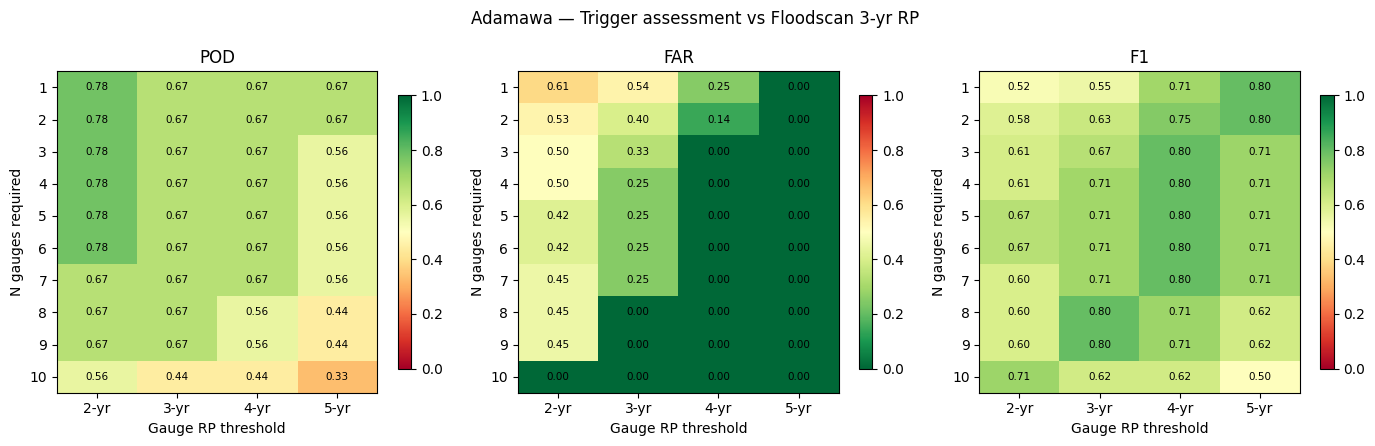

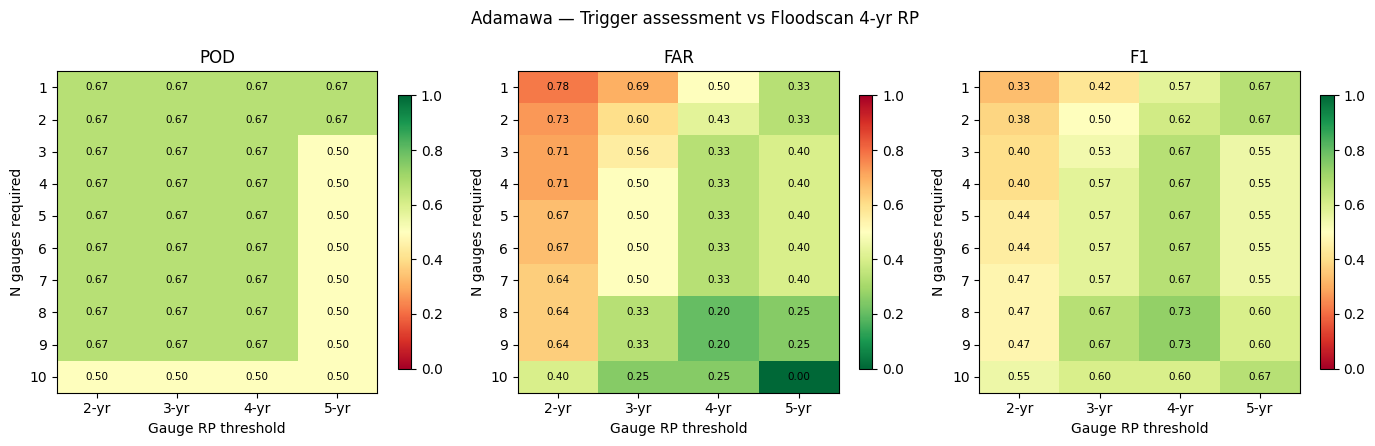

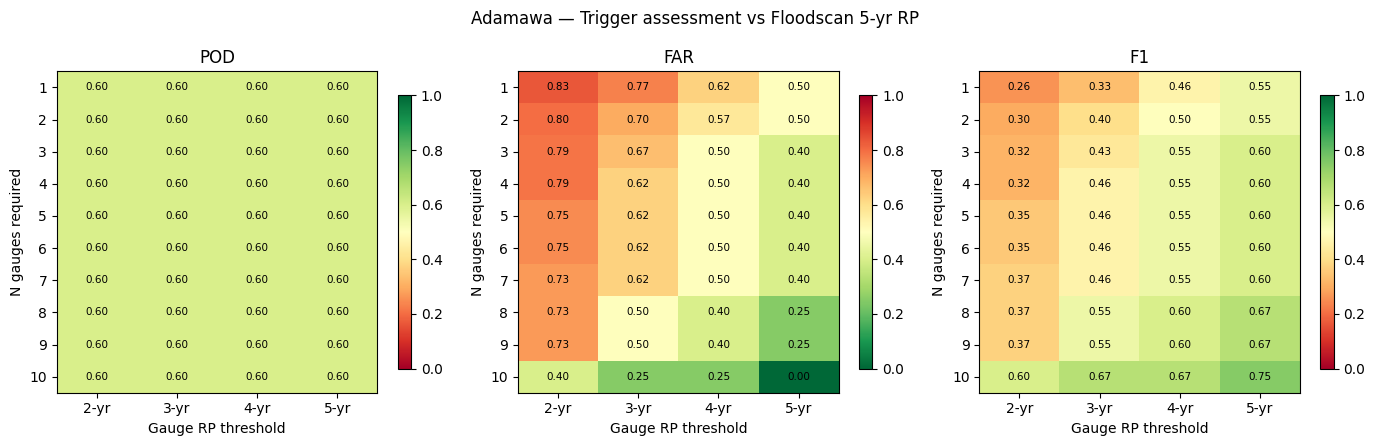

In [23]:
n_range = list(range(1, TOP_N + 1))
metrics = [("pod", "POD"), ("far", "FAR"), ("f1", "F1")]

for fs_rp in FS_RP_LEVELS:
    subset = df_grid[df_grid["fs_rp"] == fs_rp]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.suptitle(
        f"{STATE} — Trigger assessment vs Floodscan {fs_rp}-yr RP",
        fontsize=12,
    )

    for ax, (metric, label) in zip(axes, metrics):
        pivot = subset.pivot(index="n_gauges", columns="rp_thresh", values=metric)
        pivot = pivot.reindex(index=n_range, columns=RP_LEVELS)
        cmap = "RdYlGn" if metric != "far" else "RdYlGn_r"
        im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(RP_LEVELS)))
        ax.set_xticklabels([f"{r}-yr" for r in RP_LEVELS])
        ax.set_yticks(range(len(n_range)))
        ax.set_yticklabels(n_range)
        ax.set_xlabel("Gauge RP threshold")
        ax.set_ylabel("N gauges required")
        ax.set_title(label)
        plt.colorbar(im, ax=ax, shrink=0.85)
        for i, n in enumerate(n_range):
            for j, rp in enumerate(RP_LEVELS):
                val = pivot.at[n, rp] if (n in pivot.index and rp in pivot.columns) else np.nan
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=7.5, color="black")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"05_trigger_grid_fs{fs_rp}yr.png", dpi=150, bbox_inches="tight")
    plt.show()

## Best Configurations

For each Floodscan RP level, the `(RP threshold, N gauges)` pair with the highest F1 score.

In [24]:
rows = []
for fs_rp in FS_RP_LEVELS:
    sub = df_grid[df_grid["fs_rp"] == fs_rp]
    best = sub.loc[sub["f1"].idxmax()]
    rows.append({
        "Floodscan RP": f"{fs_rp}-yr",
        "Gauge RP threshold": f"{int(best['rp_thresh'])}-yr",
        "N gauges required": int(best["n_gauges"]),
        "F1":  round(best["f1"],  3),
        "POD": round(best["pod"], 3),
        "FAR": round(best["far"], 3),
        "Activations": int(best["n_activations"]),
    })

pd.DataFrame(rows)

,Floodscan RP,Gauge RP threshold,N gauges required,F1,POD,FAR,Activations
0,3-yr,3-yr,8,0.800,0.667,0.0,6
1,4-yr,4-yr,8,0.727,0.667,0.2,5
2,5-yr,5-yr,10,0.750,0.600,0.0,3


## Forecast Skill

Spearman ρ between the GRRR reforecast and the reanalysis (ground-truth streamflow), computed per gauge and per lead time, filtered to the wet season (Aug–Nov). This shows how much predictive skill degrades with increasing lead time across the selected gauges.

GloFAS reforecast is not assessed here (processed reforecast not available in blob storage for these stations).

In [25]:
if not grrr_ids:
    print("No GRRR gauges in selected set — skipping forecast skill assessment")
else:
    ds_rf = grrr.load_reforecast(gauge=grrr_ids)
    # process manually to preserve gauge_id across multiple gauges
    df_rf = ds_rf.to_dataframe().reset_index()
    df_rf["valid_time"] = pd.to_datetime(
        df_rf["issue_time"] + df_rf["lead_time"]
    ).dt.normalize()
    df_rf["leadtime"] = df_rf["lead_time"].dt.days
    df_rf = df_rf.drop(columns=["lead_time"])

    df_rf_wet = df_rf[
        df_rf["valid_time"].dt.month.isin(WET_MONTHS)
        & df_rf["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ].copy()

    print(f"Reforecast loaded: {len(grrr_ids)} gauges, "
          f"lead times 0–{df_rf['leadtime'].max()} days")
    print(f"Wet-season rows: {len(df_rf_wet):,}")

    # Spearman ρ between reforecast and reanalysis per gauge and lead time
    df_ra_lookup = (
        df_ra[df_ra["gauge_id"].isin(grrr_ids)][["date", "gauge_id", "streamflow"]]
        .rename(columns={"date": "valid_time", "streamflow": "streamflow_ra"})
    )

    skill_records = []
    for gauge_id in grrr_ids:
        merged = (
            df_rf_wet[df_rf_wet["gauge_id"] == gauge_id]
            .merge(
                df_ra_lookup[df_ra_lookup["gauge_id"] == gauge_id][["valid_time", "streamflow_ra"]],
                on="valid_time",
                how="inner",
            )
        )
        for lt in sorted(merged["leadtime"].unique()):
            sub = merged[merged["leadtime"] == lt].dropna(subset=["streamflow", "streamflow_ra"])
            if len(sub) < 20:
                continue
            r, _ = scipy_stats.spearmanr(sub["streamflow"], sub["streamflow_ra"])
            skill_records.append({"gauge_id": gauge_id, "leadtime": lt, "r": r})

    df_skill = pd.DataFrame(skill_records)
    print(f"\nMedian ρ by lead time:")
    print(df_skill.groupby("leadtime")["r"].median().round(3).to_string())

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/src/datasources/grrr.py:22: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_zarr(


Reforecast loaded: 10 gauges, lead times 0–7 days
Wet-season rows: 68,320

Median ρ by lead time:
leadtime
0    0.998
1    0.997
2    0.997
3    0.996
4    0.995
5    0.994
6    0.993
7    0.992


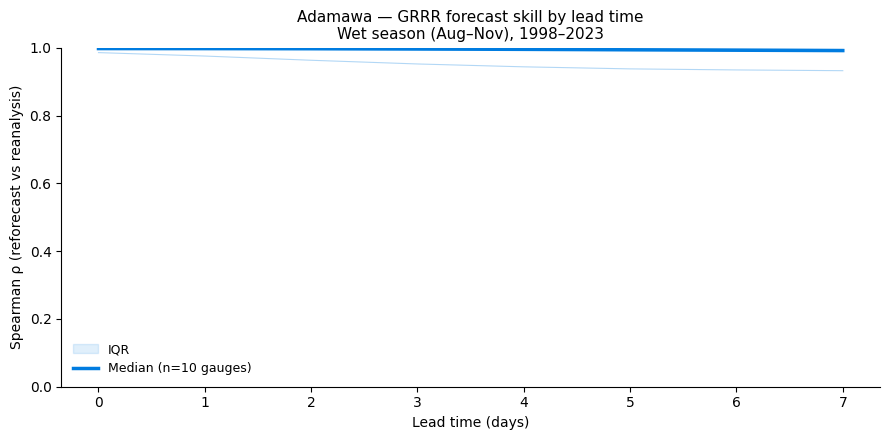

In [26]:
if "df_skill" in dir() and not df_skill.empty:
    lead_times = sorted(df_skill["leadtime"].unique())
    gauges_skill = df_skill["gauge_id"].unique()

    df_med = df_skill.groupby("leadtime")["r"].median().reset_index()
    df_iqr = df_skill.groupby("leadtime")["r"].quantile([0.25, 0.75]).unstack()

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for gauge_id in gauges_skill:
        sub = df_skill[df_skill["gauge_id"] == gauge_id].sort_values("leadtime")
        ax.plot(sub["leadtime"], sub["r"], color="#007CE0", linewidth=0.8, alpha=0.3)

    ax.fill_between(
        df_iqr.index, df_iqr[0.25], df_iqr[0.75],
        color="#007CE0", alpha=0.12, label="IQR",
    )
    ax.plot(
        df_med["leadtime"], df_med["r"],
        color="#007CE0", linewidth=2.5, label=f"Median (n={len(gauges_skill)} gauges)",
    )

    ax.set_xlabel("Lead time (days)")
    ax.set_ylabel("Spearman ρ (reforecast vs reanalysis)")
    ax.set_title(
        f"{STATE} — GRRR forecast skill by lead time\n"
        f"Wet season (Aug–Nov), {ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR}",
        fontsize=11,
    )
    ax.set_xticks(lead_times)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_forecast_skill.png", dpi=150, bbox_inches="tight")
    plt.show()

## Reforecast Bias

Mean relative bias between the reforecast and the reanalysis, per gauge and per lead time, filtered to the wet season (Aug–Nov). Positive bias means the reforecast systematically over-predicts streamflow relative to the reanalysis; negative means under-prediction.

This matters because the Gumbel thresholds in the trigger are fitted on reanalysis values — if the reforecast is biased, a gauge may systematically over- or under-trigger even at short lead times.

Mean relative bias (%) by lead time:
leadtime
0    0.3
1    0.1
2    0.3
3    0.5
4    0.7
5    1.1
6    1.5
7    1.9


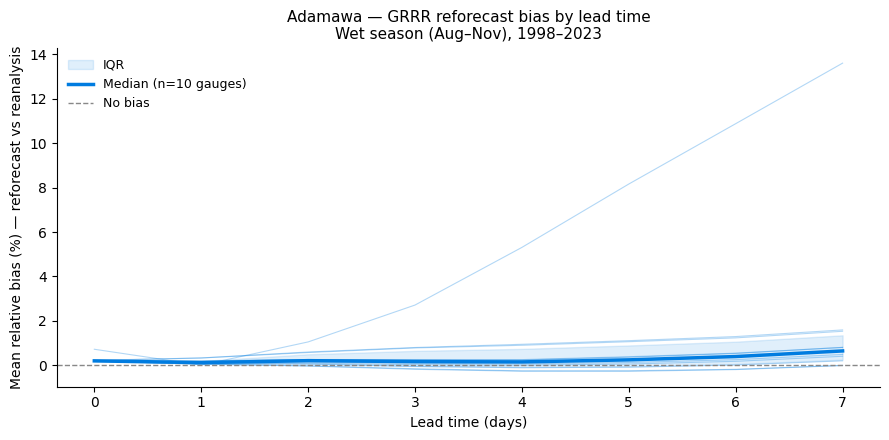

In [27]:
if "df_rf_wet" in dir() and "df_ra_lookup" in dir():
    bias_records = []
    for gauge_id in grrr_ids:
        merged = (
            df_rf_wet[df_rf_wet["gauge_id"] == gauge_id]
            .merge(
                df_ra_lookup[df_ra_lookup["gauge_id"] == gauge_id][["valid_time", "streamflow_ra"]],
                on="valid_time",
                how="inner",
            )
            .dropna(subset=["streamflow", "streamflow_ra"])
        )
        for lt in sorted(merged["leadtime"].unique()):
            sub = merged[merged["leadtime"] == lt]
            if len(sub) < 20 or sub["streamflow_ra"].mean() == 0:
                continue
            mean_rf = sub["streamflow"].mean()
            mean_ra = sub["streamflow_ra"].mean()
            rel_bias = (mean_rf - mean_ra) / mean_ra * 100
            bias_records.append({"gauge_id": gauge_id, "leadtime": lt, "rel_bias": rel_bias})

    df_bias = pd.DataFrame(bias_records)
    print("Mean relative bias (%) by lead time:")
    print(df_bias.groupby("leadtime")["rel_bias"].mean().round(1).to_string())

    lead_times  = sorted(df_bias["leadtime"].unique())
    gauges_bias = df_bias["gauge_id"].unique()

    df_bmed = df_bias.groupby("leadtime")["rel_bias"].median().reset_index()
    df_biqr = df_bias.groupby("leadtime")["rel_bias"].quantile([0.25, 0.75]).unstack()

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for gauge_id in gauges_bias:
        sub = df_bias[df_bias["gauge_id"] == gauge_id].sort_values("leadtime")
        ax.plot(sub["leadtime"], sub["rel_bias"], color="#007CE0", linewidth=0.8, alpha=0.3)

    ax.fill_between(
        df_biqr.index, df_biqr[0.25], df_biqr[0.75],
        color="#007CE0", alpha=0.12, label="IQR",
    )
    ax.plot(
        df_bmed["leadtime"], df_bmed["rel_bias"],
        color="#007CE0", linewidth=2.5, label=f"Median (n={len(gauges_bias)} gauges)",
    )
    ax.axhline(0, color="#888888", linewidth=1, linestyle="--", label="No bias")

    ax.set_xlabel("Lead time (days)")
    ax.set_ylabel("Mean relative bias (%) — reforecast vs reanalysis")
    ax.set_title(
        f"{STATE} — GRRR reforecast bias by lead time\n"
        f"Wet season (Aug–Nov), {ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR}",
        fontsize=11,
    )
    ax.set_xticks(lead_times)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_forecast_bias.png", dpi=150, bbox_inches="tight")
    plt.show()

## Save

In [28]:
stratus.upload_parquet_to_blob(df_grid, BLOB_GRID)
print(f"Saved trigger grid ({len(df_grid)} rows) to {BLOB_GRID}")

Saved trigger grid (120 rows) to ds-aa-nga-flooding/processed/workflow/adamawa_trigger_grid.parquet
